In [13]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import os 
import sys 
sys.path.append('..')
import matplotlib.pyplot as plt 
import numpy as np
import torch
from pathlib import Path
from dotenv import load_dotenv
import pickle
from datetime import datetime

import hippocampalseq as hse
import hippocampalseq.utils as hseu
import hippocampalseq.preprocessing as hsep
import hippocampalseq.models as hsem
import hippocampalseq.plotting as hsepl
import hippocampalseq.analysis as hsea
from scipy.ndimage import gaussian_filter1d


load_dotenv(Path.cwd().parent / ".env")
BASE_DIR = Path(os.environ["HSE_DATA_DIR"])
data_path = BASE_DIR
save_dir = BASE_DIR / "figures"

In [15]:
theta_time_window_s  = 20/1000#60 / 1000
theta_time_window_advance_s  = 5/1000#60 / 1000

ripple_time_window_s  = 3.0 / 1000


bin_size = 2
#data_path = os.path.realpath("../data")
rat_name = "Janni"
session = 1
track_type = "Linear"

if track_type == "Linear":
    environment_size = None
else:
    environment_size =  hsep.EnvironmentSize((0,200), (0,200))

nplot = 20


# COMBINED_DIR = BASE_DIR / 'AllAnimalsCombined'
# COMBINED_DIR.mkdir(exist_ok=True)

In [ ]:
def load_session(
    data_path, rat_name, session, *,
    track_type="Linear", environment_size=None, bin_size_cm=2,
    theta_time_window_s=20 / 1000, theta_time_window_advance_s=5 / 1000,
    velocity_cutoff_theta=10.0, placefield_kwargs=None,
):
    """Slow part: load raw data, extract theta segments, fit the momentum model.
    Call once per session, then iterate on decode_session() for free."""
    env_size = None if track_type == "Linear" else (environment_size or hsep.EnvironmentSize((0, 200), (0, 200)))

    pf_kwargs = dict(place_field_posterior=False, velocity_cutoff=5.0,
                      place_field_gaussian_sd_cm=4.0, flatten_linear=True)
    if placefield_kwargs:
        pf_kwargs.update(placefield_kwargs)

    raw_data, place_field_data = hse.load_raw_data(
        data_path, rat_name, session, track_type=track_type,
        environment_size=env_size, bin_size_cm=bin_size_cm, placefield_kwargs=pf_kwargs,
    )
    theta_data = hse.process_theta(
        raw_data, place_field_data, velocity_cutoff=velocity_cutoff_theta,
        theta_kwargs={"time_window_s": theta_time_window_s,
                      "time_window_advance_s": theta_time_window_advance_s},
    )
    place_fields = place_field_data.place_fields[place_field_data.place_cell_ids]
    if place_fields.shape[0] != theta_data.spikes[0].shape[1]:
        raise ValueError(
            f"{rat_name} session {session}: cell count mismatch "
            f"({place_fields.shape[0]} place fields vs {theta_data.spikes[0].shape[1]} spike rows)"
        )

    momentum = hsem.Momentum(
        dt=theta_time_window_s, bin_size=bin_size_cm,
        environment_size=raw_data.environment_size,
        place_fields=place_fields, spikemat_train=theta_data.spikes,
    )

    return {
        "rat_name": rat_name, "session": session, "track_type": track_type,
        "raw_data": raw_data, "theta_data": theta_data, "momentum": momentum,
        "bin_size_cm": bin_size_cm,
    }

def run_all_decoding(data_path, animal_sessions, save_dir, *, filename_tag="momentum_decoding", **load_kwargs):
    """Loop load_session over every (rat, session) and pickle just what's needed
    for post-hoc decoding analysis (emission_probabilities, environment_size,
    ground_truth, spikes)

    animal_sessions: {"Janni": [1, 2, 3, 4], "Harpy": [1, 2, 3, 4], "Imp": [1]}
    """
    date_folder = datetime.now().strftime('%Y-%m-%d')
    pickle_dir = os.path.join(save_dir, date_folder, filename_tag, "decoding_pickles")
    os.makedirs(pickle_dir, exist_ok=True)

    failures = {}
    for rat_name, sessions in animal_sessions.items():
        for session in sessions:
            tag = f"{rat_name}_session{session}"
            print(f"--- {tag} ---")
            try:
                loaded = load_session(data_path, rat_name, session, **load_kwargs)
            except Exception as exc:
                print(f"  FAILED: {exc!r}")
                failures[tag] = repr(exc)
                continue

            decoding_out = {
                "rat_name": rat_name,
                "session": session,
                "track_type": loaded["track_type"],
                "bin_size_cm": loaded["bin_size_cm"],
                "emission_probabilities": loaded["momentum"].emission_probabilities,
                "environment_size": loaded["raw_data"].environment_size,
                "ground_truth": loaded["theta_data"].ground_truth,
                "spikes": loaded["theta_data"].spikes,
            }
            with open(os.path.join(pickle_dir, f"{tag}.pkl"), "wb") as f:
                pickle.dump(decoding_out, f)

    if failures:
        print(f"\n{len(failures)} session(s) failed:")
        for tag, err in failures.items():
            print(f"  {tag}: {err}")

    return pickle_dir, failures


def load_all_decoding(pickle_dir):
    """Reconstruct {rat: {session: decoding_out}} from run_all_decoding's pickles."""
    pickle_dir = Path(pickle_dir)
    all_decoding = {}
    for pkl_path in sorted(pickle_dir.glob("*.pkl")):
        with open(pkl_path, "rb") as f:
            decoding_out = pickle.load(f)
        all_decoding.setdefault(decoding_out["rat_name"], {})[decoding_out["session"]] = decoding_out
    n = sum(len(v) for v in all_decoding.values())
    print(f"Loaded {n} sessions' decoding output from {pickle_dir}")
    return all_decoding


def run_all_peak_posterior(all_decoding, *, peak_posterior_kwargs=None):
    pp_kwargs = dict(peak_posterior_kwargs or {})

    all_results = {}
    for rat_name, sessions in all_decoding.items():
        all_results[rat_name] = {}
        for session, dec in sessions.items():
            kw = dict(pp_kwargs)
            kw.setdefault("bin_size_cm", dec["bin_size_cm"])
            results = {
                name: hsea.peak_posterior_new(
                    dec["emission_probabilities"], dec["environment_size"],
                    dec["ground_truth"], dec["spikes"], direction=dr, **kw,
                )
                for name, dr in (("both", None), ("pos", 1.0), ("neg", -1.0))
            }
            all_results[rat_name][session] = {
                "rat_name": rat_name, "session": session,
                "track_type": dec["track_type"], "results": results,
            }
    return all_results

In [53]:
import warnings

ANIMAL_SESSIONS = {
    "Janni": [1,2,3,4],   # fill in real session numbers per rat
    "Harpy": [1,2,3,4],
    "Imp":   [1,],
}

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    pickle_dir, failures = run_all_decoding(data_path, ANIMAL_SESSIONS, save_dir)

--- Janni_session1 ---
Sample rate: nominal=3255.60 Hz, actual median dt=3255.2166 Hz, drift=+117.8 ppm
LFP data range: 3885.0 - 11772.3s (duration: 7887.3s)
Found 1 run session(s)
  Session 1:
    Position: 5688.1 - 6867.9s
    Spikes:   5688.1 - 6867.9s
Loading data took 20.134760856628418s
Calculating place fields took 0.1131143569946289s
Dropping LFP metadata. If you want it, call the functions yourself
Detecting theta cycles took 0.6381011009216309s
Matched 428604 spikes to LFP. |Δt| (median/IQR): 0.08 ms / 0.08 ms
Aligning spikes to theta phase took 0.507556676864624
Extracting theta run sequences took 1.4620802402496338
--- Janni_session2 ---
Removing 2 noisy epochs
Sample rate: nominal=3255.60 Hz, actual median dt=3255.2166 Hz, drift=+117.8 ppm
LFP data range: 11899.6 - 21213.9s (duration: 9314.3s)
Found 1 run session(s)
  Session 1:
    Position: 15643.1 - 16727.9s
    Spikes:   15643.1 - 16727.9s
Loading data took 18.433817625045776s
Calculating place fields took 0.1082847118

In [44]:
# with warnings.catch_warnings():
#     warnings.simplefilter("ignore")
#     all_results, failures = run_all_sessions(
#         data_path, ANIMAL_SESSIONS, save_dir,
#         filename_tag="momentum_decoding",
#         bin_size_cm=2,
#     )

In [ ]:
def pool_sessions_norm_dist(all_results, direction="both", weight_by_oscillations=False):
    """Pool per-session norm_dist matrices from run_all_sessions into one distribution.

    direction: 'both' | 'pos' | 'neg'
    """
    dists, weights = [], []
    for rat_name, sessions in all_results.items():
        for session, session_out in sessions.items():
            r = session_out["results"][direction]
            dists.append(r["norm_dist"])
            weights.append(r["n_oscillations_used"] if weight_by_oscillations else 1.0)

    stack = np.stack(dists, axis=-1)              # (n_pos, n_phase, n_sessions)
    weights = np.asarray(weights, dtype=float)
    pooled = np.nansum(stack * weights, axis=-1) / weights.sum()

    scheme = "oscillation-weighted" if weight_by_oscillations else "equal-weighted"
    print(f"Pooled '{direction}' decoding distribution from {len(dists)} sessions ({scheme})")
    return pooled


def plot_pooled_decoding_distribution(pooled_dec_dist, phase_bin=10, position_bin=2,
                                    n_cycles=2, direction_label="both", save_dir=None):
    """Heatmap + max-probability trace of a pooled decoding distribution.

    No forward/reverse window lines or slope fits here because they need editing
    """
    n_pos, n_phase = pooled_dec_dist.shape
    doubled = np.concatenate([pooled_dec_dist] * n_cycles, axis=1)
    n_phase_doubled = doubled.shape[1]

    fig, axes = plt.subplots(2, 1, figsize=(12, 8),
                            gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

    mid_row = n_pos // 2
    pos_extent = [-mid_row * position_bin, (n_pos - 1 - mid_row) * position_bin]

    im = axes[0].imshow(
        doubled, aspect='auto', origin='lower', cmap='hot',
        extent=[0, n_phase_doubled * phase_bin, pos_extent[0], pos_extent[1]],
        vmin=0, vmax=doubled.max(), interpolation="nearest",
    )
    axes[0].set_ylabel('Decoded position\nrelative to rat (cm)', fontsize=11)
    axes[0].set_title(f'Pooled peak posterior distribution ({direction_label})', fontsize=11)
    plt.colorbar(im, ax=axes[0], label='Normalized probability', pad=0.02)

    max_prob_smooth = gaussian_filter1d(doubled.max(axis=0), sigma=1.0)
    phase_axis_deg = np.arange(n_phase_doubled) * phase_bin + phase_bin / 2
    axes[1].plot(phase_axis_deg, max_prob_smooth, 'ko-', linewidth=2, markersize=4)
    axes[1].set_xlabel('Theta phase (deg)', fontsize=11)
    axes[1].set_ylabel('Max\nposterior', fontsize=11)
    axes[1].set_xlim(0, n_phase_doubled * phase_bin)
    axes[1].set_xticks(np.arange(0, n_phase_doubled * phase_bin + 1, 90))

    plt.tight_layout()

    if save_dir is not None:
        from pathlib import Path
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)
        path = save_dir / f'pooled_decoding_{direction_label}.png'
        plt.savefig(path, dpi=600, bbox_inches='tight')
        print(f"Saved to {path}")

    plt.show()
    return {'doubled_distribution': doubled}

In [47]:


# def load_pooled_results(pickle_dir):
#     """Reconstruct the all_results nested dict from pickled run_session_decoding outputs.

#     pickle_dir: folder of <rat>_session<n>.pkl files, e.g.
#         save_dir / "<date>" / "momentum_decoding" / "pickles"
#     """
#     pickle_dir = Path(pickle_dir)
#     all_results = {}
#     for pkl_path in sorted(pickle_dir.glob("*.pkl")):
#         with open(pkl_path, "rb") as f:
#             session_out = pickle.load(f)
#         all_results.setdefault(session_out["rat_name"], {})[session_out["session"]] = session_out

#     n_sessions = sum(len(v) for v in all_results.values())
#     print(f"Loaded {n_sessions} sessions from {pickle_dir}")
#     return all_results

Loaded 9 sessions' decoding output from /work/bioinformatics/s437598/New_Brad_Data/_CleanDataSetForSharing/figures/2026-09-21/momentum_decoding/decoding_pickles
['rat_name', 'session', 'track_type', 'bin_size_cm', 'emission_probabilities', 'environment_size', 'ground_truth', 'spikes']
2409 oscillations pass flags; 807 selected (>= 42 spikes in (80, 240))
1414 oscillations pass flags; 485 selected (>= 42 spikes in (80, 240))
995 oscillations pass flags; 334 selected (>= 41 spikes in (80, 240))
2093 oscillations pass flags; 699 selected (>= 45 spikes in (80, 240))
1115 oscillations pass flags; 376 selected (>= 44 spikes in (80, 240))
978 oscillations pass flags; 335 selected (>= 45 spikes in (80, 240))
6205 oscillations pass flags; 2168 selected (>= 33 spikes in (80, 240))
3009 oscillations pass flags; 1042 selected (>= 35 spikes in (80, 240))
3196 oscillations pass flags; 1080 selected (>= 32 spikes in (80, 240))
4473 oscillations pass flags; 1550 selected (>= 20 spikes in (80, 240))
22

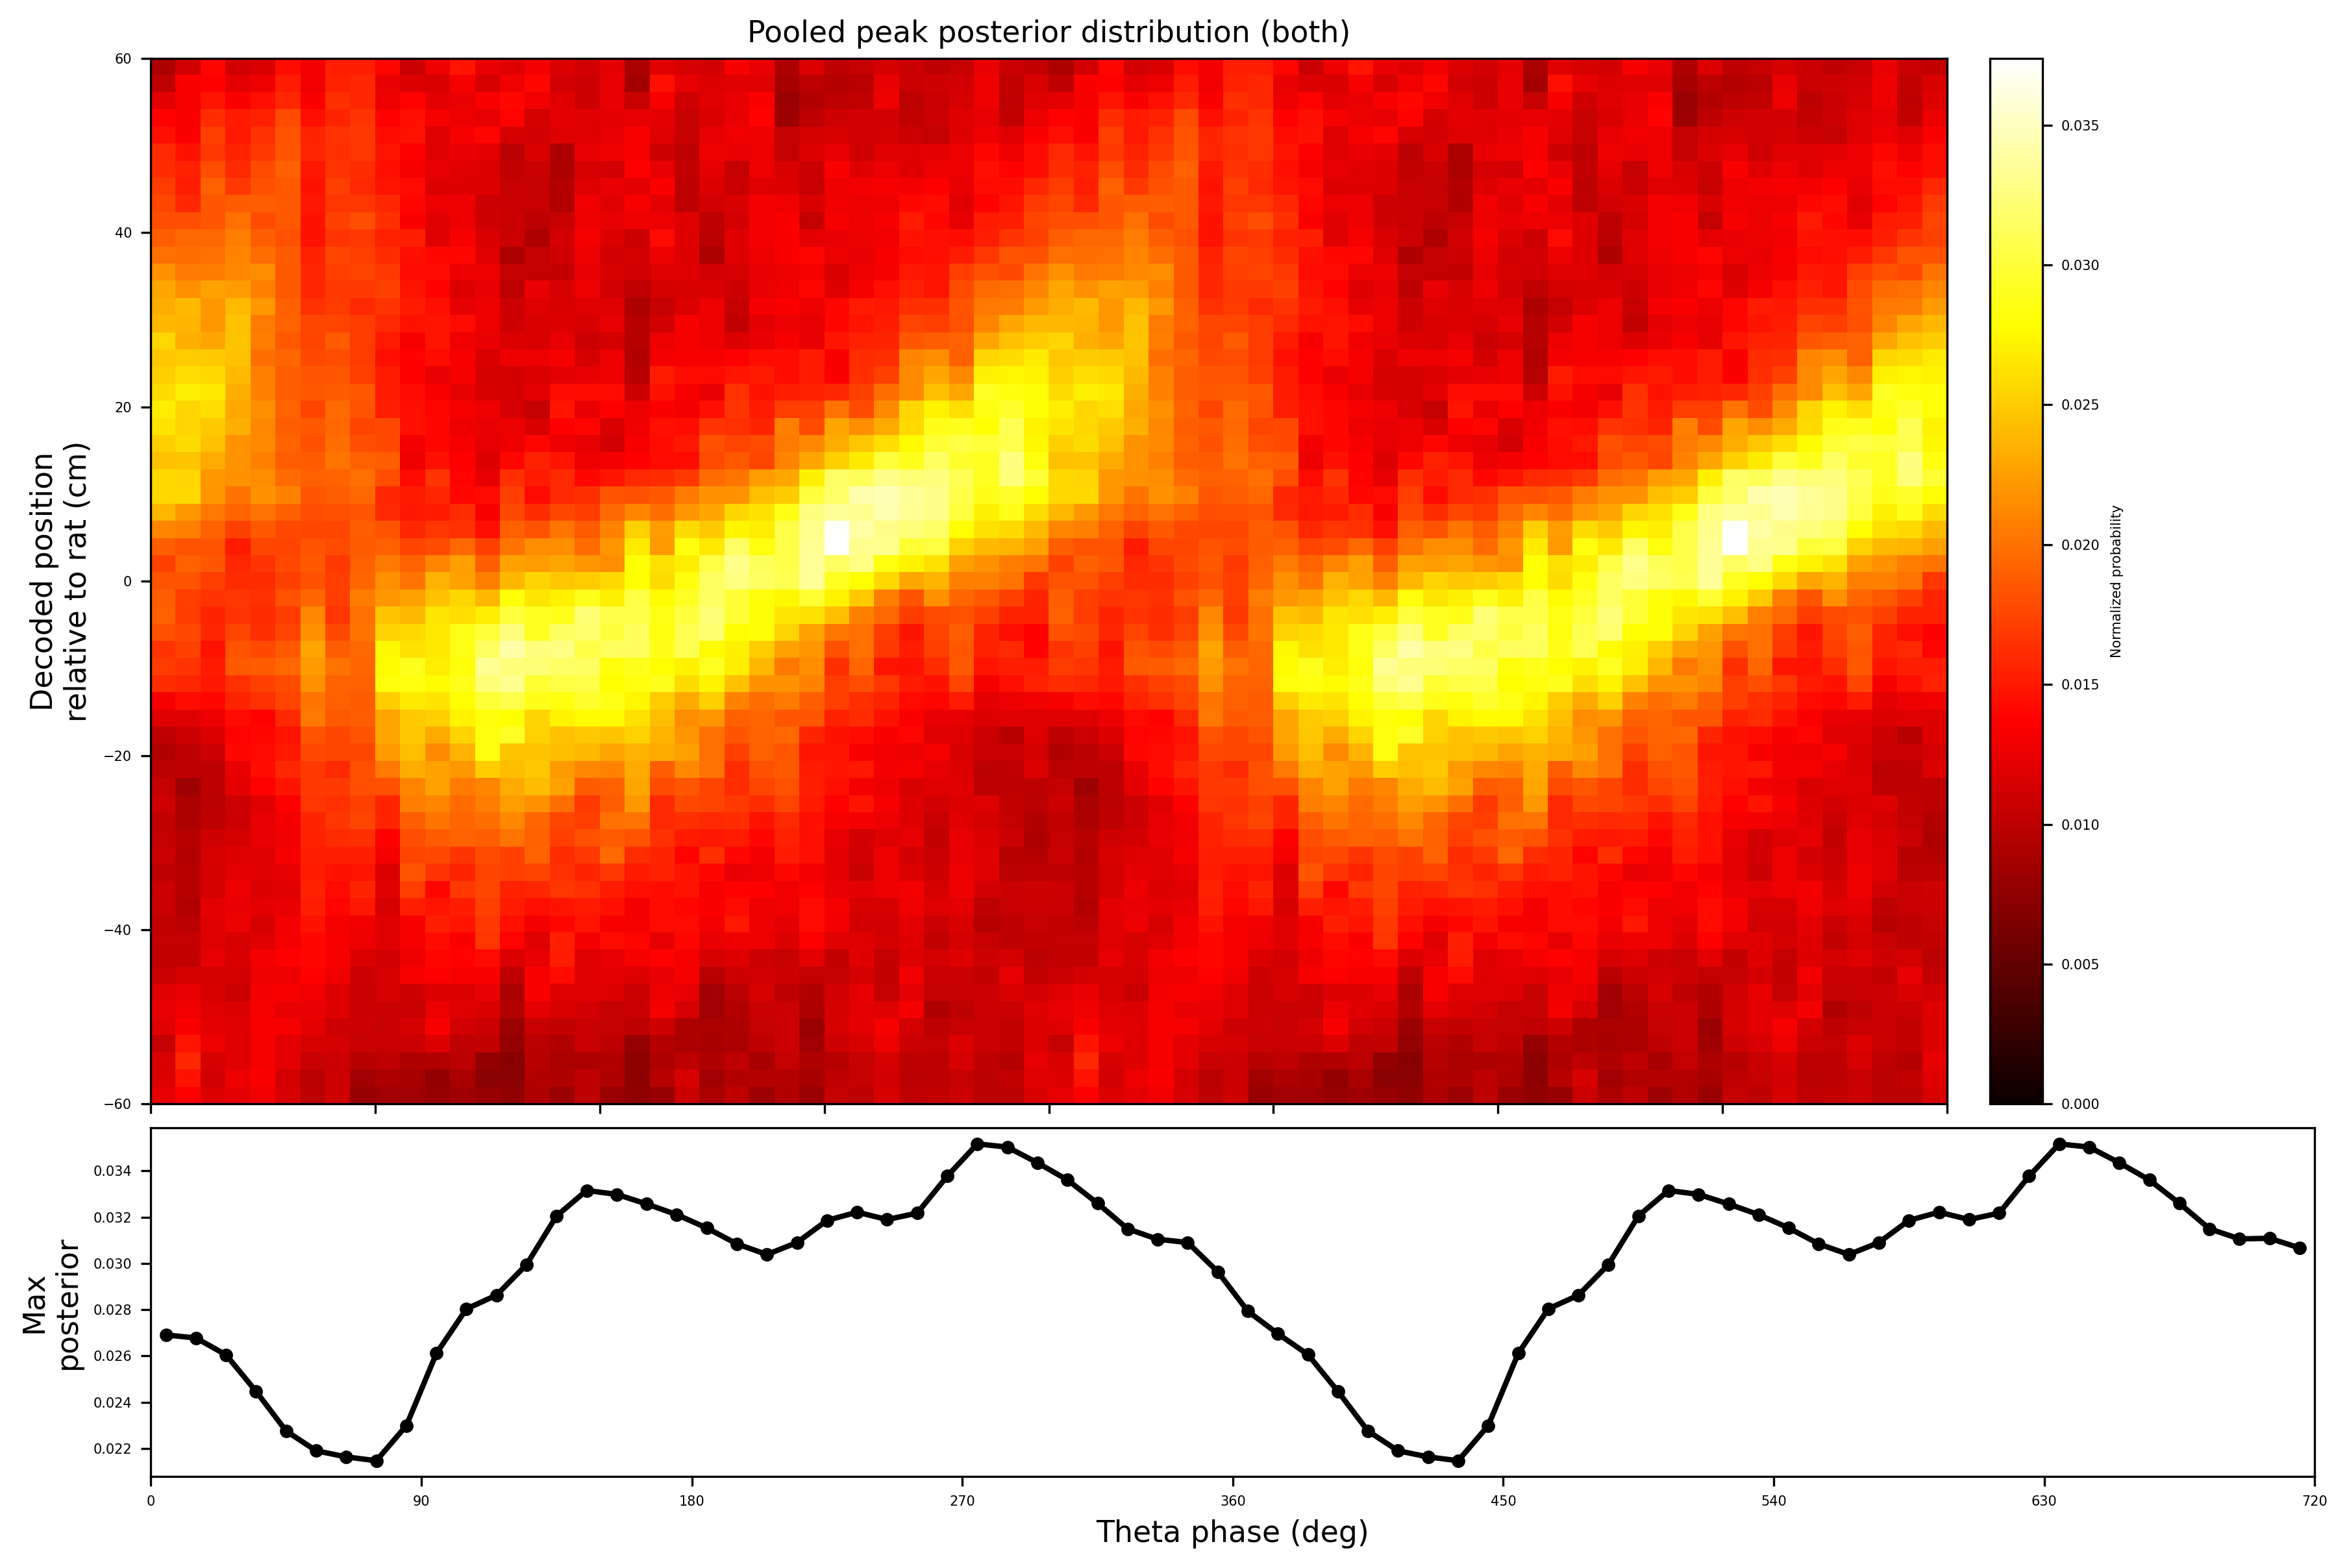

{'doubled_distribution': array([[0.01231324, 0.01371212, 0.01177843, ..., 0.00987074, 0.00992771,
         0.01158686],
        [0.01179677, 0.01466855, 0.01114015, ..., 0.00985156, 0.01026091,
         0.01207269],
        [0.01158274, 0.01580427, 0.01146683, ..., 0.01018194, 0.00962975,
         0.01238121],
        ...,
        [0.01217364, 0.01342125, 0.0148512 , ..., 0.01277994, 0.01010008,
         0.01184325],
        [0.01016944, 0.01350161, 0.01361694, ..., 0.01276125, 0.01028945,
         0.01165995],
        [0.00918442, 0.01115204, 0.01390982, ..., 0.01245777, 0.01079439,
         0.01035477]], shape=(61, 72))}

In [54]:
phase_bin = 10
initial_forward_window = [200, 70]    
initial_reverse_window = [80, 190] 


#pickle_dir = save_dir / "2026-09-21" / "momentum_decoding" / "pickles"   # adjust date/tag
# all_results = load_pooled_results(pickle_dir)

# pooled_both = pool_sessions_norm_dist(all_results, direction="both",weight_by_oscillations=False)
# plot_pooled_decoding_distribution(pooled_both, phase_bin=phase_bin, direction_label="both", save_dir=save_dir)


# pooled_by_direction = {}
# for direction in ("both", "pos", "neg"):
#     pooled = pool_sessions_norm_dist(all_results, direction=direction)
#     pooled_by_direction[direction] = pooled
#     plot_pooled_decoding_distribution(
#         pooled, phase_bin=phase_bin, direction_label=direction, save_dir=save_dir
#     )

all_decoding = load_all_decoding(pickle_dir)

all_results = run_all_peak_posterior(all_decoding)


In [ ]:

pooled_both = pool_sessions_norm_dist(all_results, direction="both")
plot_pooled_decoding_distribution(pooled_both, phase_bin=phase_bin, direction_label="both", save_dir=save_dir)

both: n_oscillations_used=1075


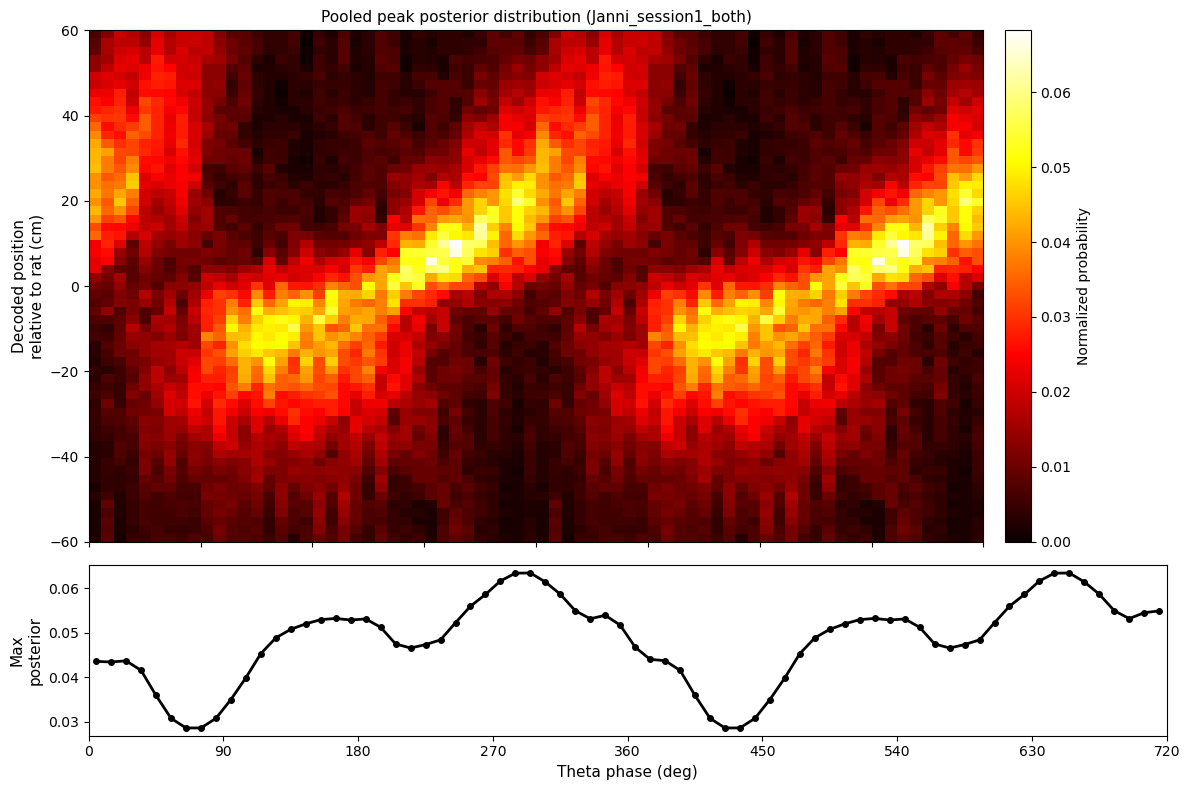

pos: n_oscillations_used=593


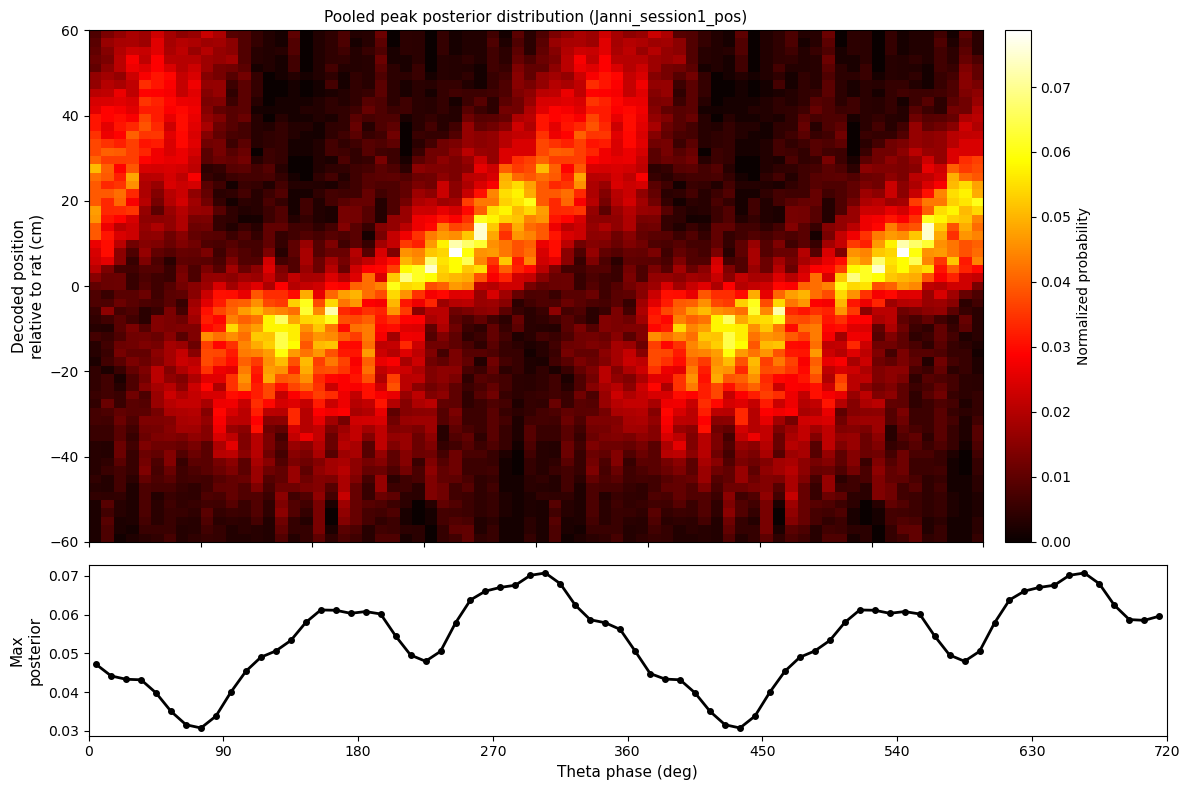

neg: n_oscillations_used=488


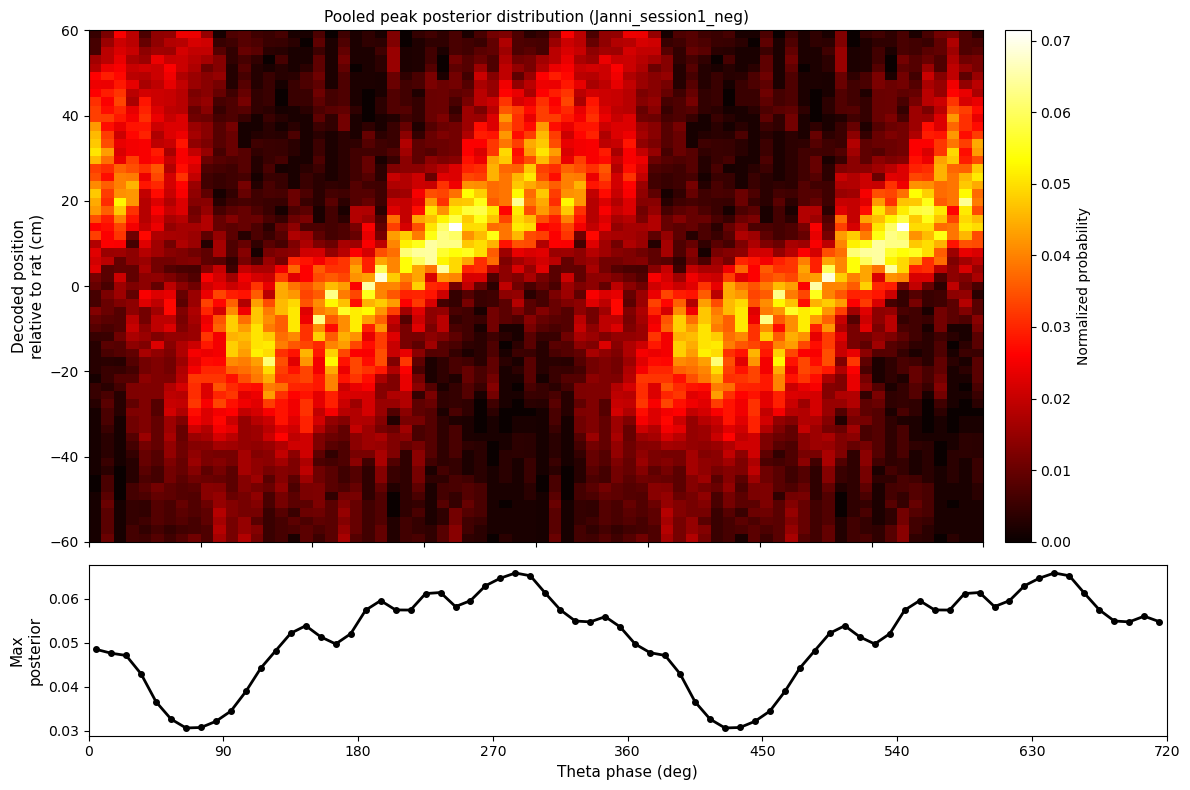

In [ ]:
# pick a session you already suspect looks good
session_out = all_results["Harpy"][3]  # swap animal/session as needed

for direction in ("both", "pos", "neg"):
    r = session_out["results"][direction]
    print(f"{direction}: n_oscillations_used={r['n_oscillations_used']}")
    plot_pooled_decoding_distribution(
        r["norm_dist"], phase_bin=phase_bin, direction_label=f"Harpy_session3_{direction}",
        save_dir=None,   # skip saving while you're just eyeballing
    )

In [18]:
def plot_single_oscillation_diagnostic(
    emission_probabilities, segments, spikemats, environment_size,
    oscillation_number, *, bin_size_cm=2, half_width=30, map_decoded=None,
):
    grid = hseu.make_ndgrid(environment_size, bin_size_cm, indexing='ij').numpy()[:, 0]
    axis_col = environment_size.axes()[0]
    v_col = 'V_' + axis_col
    n_pos = 2 * half_width + 1
    dist_edges = (np.arange(n_pos + 1) - half_width - 0.5) * bin_size_cm

    osc_offset = 0
    ep = frame = idx = seg_idx = None
    for i, (ep_i, frame_i, spk_i) in enumerate(zip(emission_probabilities, segments, spikemats)):
        osc = frame_i['Oscillation Number'].values.astype(int) + osc_offset
        m = osc == oscillation_number
        if m.any():
            ep, frame, idx, seg_idx = ep_i, frame_i, np.flatnonzero(m), i
            break
        osc_offset = osc.max() + 1
    if frame is None:
        raise ValueError(f"Oscillation {oscillation_number} not found")

    ep_np = ep.detach().numpy().reshape(len(ep), -1)[idx]
    pos = frame[axis_col].values[idx]
    phase = np.mod(frame['Phase Deg'].values[idx], 360.0)
    d = np.sign(frame[v_col].values[idx])
    d[d == 0] = 1.0

    R = np.zeros((n_pos, len(idx)))
    for t in range(len(idx)):
        dbin = np.digitize((grid - pos[t]) * d[t], dist_edges) - 1
        ok = (dbin >= 0) & (dbin < n_pos)
        np.add.at(R[:, t], dbin[ok], ep_np[t][ok])
    peak_rel = (R.argmax(axis=0) - half_width) * bin_size_cm

    fig, ax = plt.subplots(figsize=(6, 5))
    mid_row = n_pos // 2
    pos_extent = [-mid_row * bin_size_cm, (n_pos - 1 - mid_row) * bin_size_cm]
    im = ax.imshow(R, aspect='auto', origin='lower', cmap='hot',
                    extent=[phase.min(), phase.max(), pos_extent[0], pos_extent[1]],
                    interpolation='nearest')
    ax.plot(phase, peak_rel, 'c-o', label='per-window argmax (emission)')

    if map_decoded is not None:
        map_pos = np.asarray(map_decoded.decoded_trajectories[seg_idx])[idx, 0]
        map_rel = (map_pos - pos) * d           # now per-window d, not scalar
        ax.plot(phase, map_rel, 'w-s', markeredgecolor='k', label='BayesianMAP')

    ax.axhline(0, color='gray', linestyle=':', linewidth=1)
    ax.set_xlabel('Theta phase (deg)')
    ax.set_ylabel('Position relative to rat (cm)')
    ax.set_title(f'Oscillation {oscillation_number}  (n_windows={len(idx)})')
    ax.legend(loc='best', fontsize=8)
    plt.colorbar(im, ax=ax, label='Emission probability (summed per bin)')
    plt.tight_layout()
    plt.show()

    return {'phase': phase, 'peak_rel_cm': peak_rel, 'R': R}

In [16]:
theta_time_window_s  = 20/1000#60 / 1000
theta_time_window_advance_s  = 5/1000#60 / 1000

ripple_time_window_s  = 3.0 / 1000


bin_size = 2
#data_path = os.path.realpath("../data")
rat_name = "Janni"
session = 1
track_type = "Linear"

if track_type == "Linear":
    environment_size = None
else:
    environment_size =  hsep.EnvironmentSize((0,200), (0,200))

nplot = 20

In [9]:
(raw_data, place_field_data) = hse.load_raw_data(
    data_path, rat_name, session,
    track_type=track_type, environment_size=environment_size, bin_size_cm=bin_size,
    placefield_kwargs={'place_field_posterior': False,
                    'velocity_cutoff': 5.0,             # paper: fields from >= 5 cm/s
                    'place_field_gaussian_sd_cm': 4.0,  # paper: sigma = 4 cm
                    'flatten_linear': True},
)
theta_data = hse.process_theta(
    raw_data, place_field_data, velocity_cutoff=10.0,
    theta_kwargs={'time_window_s': theta_time_window_s,
                'time_window_advance_s': theta_time_window_advance_s},
)
place_fields = place_field_data.place_fields[place_field_data.place_cell_ids]
print(place_fields.shape, theta_data.spikes[0].shape)     # cell counts must match

%store raw_data place_field_data theta_data

/home2/s437598/miniconda3/envs/hippocampalswr/lib/python3.14/site-packages/pynapple/core/base_class.py:50: UserWarning: Some epochs have no duration
  self.time_support = IntervalSet(start=self.index[0], end=self.index[-1])
/home2/s437598/miniconda3/envs/hippocampalswr/lib/python3.14/site-packages/pynapple/core/base_class.py:52: RuntimeWarning: divide by zero encountered in scalar divide
  self.rate = self.index.shape[0] / np.sum(
/home2/s437598/miniconda3/envs/hippocampalswr/lib/python3.14/site-packages/pynapple/core/base_class.py:50: UserWarning: Some epochs have no duration
  self.time_support = IntervalSet(start=self.index[0], end=self.index[-1])
/home2/s437598/miniconda3/envs/hippocampalswr/lib/python3.14/site-packages/pynapple/core/base_class.py:52: RuntimeWarning: divide by zero encountered in scalar divide
  self.rate = self.index.shape[0] / np.sum(
/home2/s437598/miniconda3/envs/hippocampalswr/lib/python3.14/site-packages/pynapple/core/base_class.py:50: UserWarning: Some epoch

Sample rate: nominal=3255.60 Hz, actual median dt=3255.2166 Hz, drift=+117.8 ppm
LFP data range: 3885.0 - 11772.3s (duration: 7887.3s)
Found 1 run session(s)
  Session 1:
    Position: 5688.1 - 6867.9s
    Spikes:   5688.1 - 6867.9s


/project/bioinformatics/WZhang_lab/s437598/PO-OU/notebooks/../hippocampalseq/io/lfp.py:174: UserWarning:     -> overlap 5688.1 - 6867.9s
  warnings.warn(f'    -> overlap {overlap_start:.1f} - {overlap_end:.1f}s')


Loading data took 20.908117532730103s
Calculating place fields took 0.11662960052490234s
Dropping LFP metadata. If you want it, call the functions yourself


/project/bioinformatics/WZhang_lab/s437598/PO-OU/notebooks/../hippocampalseq/preprocessing/theta.py:269: UserWarning: 0/8574 theta cycles boundary-rejected
  warnings.warn(f"{n_skipped_boundary}/{n_valid} theta cycles boundary-rejected")
/project/bioinformatics/WZhang_lab/s437598/PO-OU/notebooks/../hippocampalseq/preprocessing/theta.py:270: UserWarning: 1050/8574 theta cycles length filtered
  warnings.warn(f"{n_skipped_length}/{n_valid} theta cycles length filtered")


Detecting theta cycles took 0.6448004245758057s
Matched 428604 spikes to LFP. |Δt| (median/IQR): 0.08 ms / 0.08 ms
Aligning spikes to theta phase took 0.5181925296783447
Extracting theta run sequences took 1.4812147617340088
(89, 89, 1) (703, 89)
Stored 'raw_data' (RawData)
Stored 'place_field_data' (PlaceFields)
Stored 'theta_data' (Theta)


In [10]:
momentum = hsem.Momentum(
    dt=theta_time_window_s,
    bin_size=bin_size,
    environment_size=raw_data.environment_size,
    place_fields=place_fields,
    spikemat_train=theta_data.spikes
)

bmap = hsem.BayesianMAP(
    place_fields=place_fields,
    dt=theta_time_window_s,
    bin_size=bin_size
)
map_decoded = bmap.fit(theta_data.spikes)

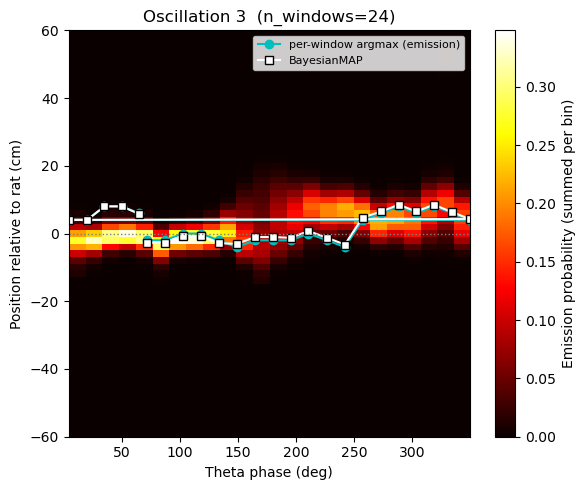

In [20]:
bmap = hsem.BayesianMAP(place_fields=place_fields, dt=theta_time_window_s, bin_size=bin_size)
map_decoded = bmap.fit(theta_data.spikes)

osc_to_check = 3  # any oscillation number that occurs in theta_data.ground_truth

diag = plot_single_oscillation_diagnostic(
    momentum.emission_probabilities, theta_data.ground_truth, theta_data.spikes,
    raw_data.environment_size, osc_to_check,
    bin_size_cm=bin_size, map_decoded=map_decoded,
)

In [24]:
print(type(map_decoded.decoded_trajectories))
print(len(map_decoded.decoded_trajectories))
print(type(map_decoded.decoded_trajectories[0]), map_decoded.decoded_trajectories[0].shape)

<class 'list'>
93
<class 'numpy.ndarray'> (686, 1)


In [ ]:
def plot_continuous_trajectory(
    emission_probabilities, segments, spikemats, environment_size,
    seg_idx, *, osc_range=None, bin_size_cm=2, half_width=30,
):

    grid = hseu.make_ndgrid(environment_size, bin_size_cm, indexing='ij').numpy()[:, 0]
    axis_col = environment_size.axes()[0]
    v_col = 'V_' + axis_col
    n_pos = 2 * half_width + 1
    dist_edges = (np.arange(n_pos + 1) - half_width - 0.5) * bin_size_cm

    ep = emission_probabilities[seg_idx]
    frame = segments[seg_idx]
    osc = frame['Oscillation Number'].values

    m = np.ones(len(frame), dtype=bool) if osc_range is None else \
        (osc >= osc_range[0]) & (osc <= osc_range[1])
    idx = np.flatnonzero(m)

    ep_np = ep.detach().numpy().reshape(len(ep), -1)[idx]
    pos = frame[axis_col].values[idx]
    t = frame.index.values[idx]
    t_ms = (t - t[0]) * 1000.0
    phase = frame['Phase Deg'].values[idx]
    d = np.sign(frame[v_col].values[idx])
    d[d == 0] = 1.0

    R = np.zeros((n_pos, len(idx)))
    for i in range(len(idx)):
        dbin = np.digitize((grid - pos[i]) * d[i], dist_edges) - 1
        ok = (dbin >= 0) & (dbin < n_pos)
        np.add.at(R[:, i], dbin[ok], ep_np[i][ok])

    change = np.flatnonzero(np.diff(osc[idx]) != 0)
    osc_boundaries_ms = (t_ms[change] + t_ms[change + 1]) / 2

    fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True,
                              gridspec_kw={'height_ratios': [1, 3]})

    axes[0].plot(t_ms, np.cos(np.deg2rad(phase)), 'k-', linewidth=1)
    axes[0].set_ylabel('Theta\n(cos phase)')
    axes[0].set_yticks([])

    mid_row = n_pos // 2
    pos_extent = [-mid_row * bin_size_cm, (n_pos - 1 - mid_row) * bin_size_cm]
    im = axes[1].imshow(R, aspect='auto', origin='lower', cmap='hot',
                         extent=[t_ms.min(), t_ms.max(), pos_extent[0], pos_extent[1]],
                         interpolation='nearest')
    axes[1].axhline(0, color='c', linewidth=1, alpha=0.7)
    for b in osc_boundaries_ms:
        axes[0].axvline(b, color='gray', linestyle=':', linewidth=0.7)
        axes[1].axvline(b, color='white', linestyle=':', linewidth=0.7, alpha=0.5)

    axes[1].set_xlabel('Time (ms)')
    axes[1].set_ylabel('Relative Loc. (cm)')
    plt.colorbar(im, ax=axes[1], label='Emission probability', pad=0.02)
    plt.tight_layout()
    plt.show()

    return {'t_ms': t_ms, 'R': R, 'osc_boundaries_ms': osc_boundaries_ms}

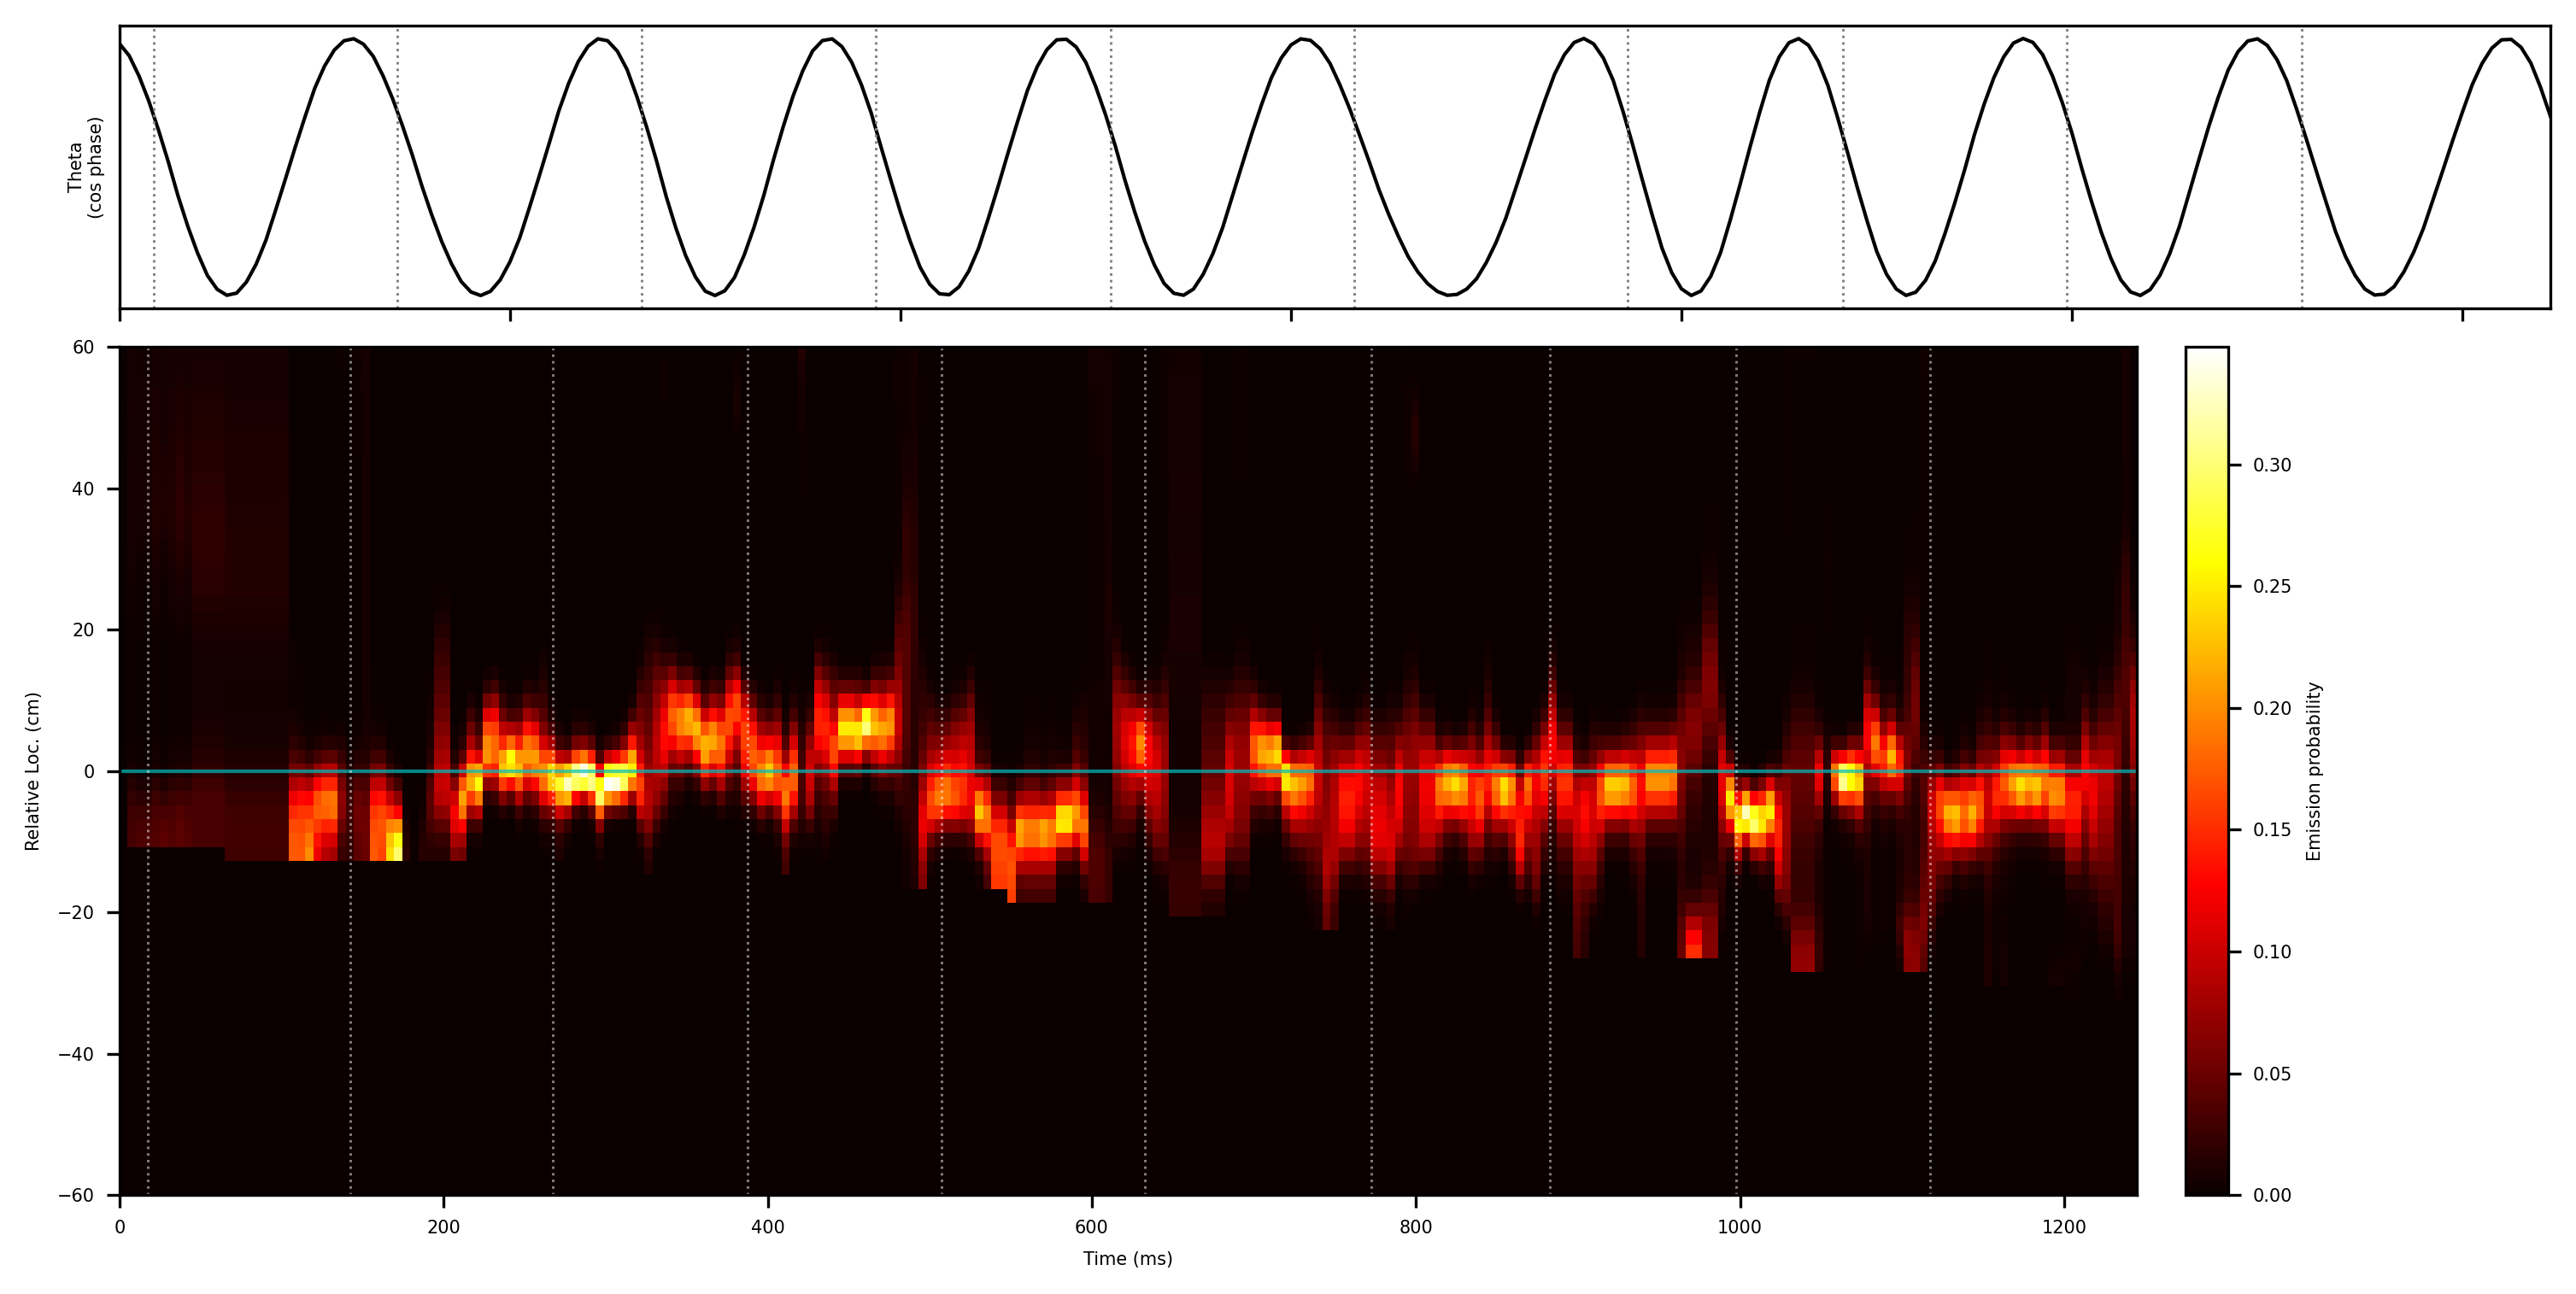

{'t_ms': array([   0.,    5.,   10.,   15.,   20.,   25.,   30.,   35.,   40.,
          45.,   50.,   55.,   60.,   65.,   70.,   75.,   80.,   85.,
          90.,   95.,  100.,  105.,  110.,  115.,  120.,  125.,  130.,
         135.,  140.,  145.,  150.,  155.,  160.,  165.,  170.,  175.,
         180.,  185.,  190.,  195.,  200.,  205.,  210.,  215.,  220.,
         225.,  230.,  235.,  240.,  245.,  250.,  255.,  260.,  265.,
         270.,  275.,  280.,  285.,  290.,  295.,  300.,  305.,  310.,
         315.,  320.,  325.,  330.,  335.,  340.,  345.,  350.,  355.,
         360.,  365.,  370.,  375.,  380.,  385.,  390.,  395.,  400.,
         405.,  410.,  415.,  420.,  425.,  430.,  435.,  440.,  445.,
         450.,  455.,  460.,  465.,  470.,  475.,  480.,  485.,  490.,
         495.,  500.,  505.,  510.,  515.,  520.,  525.,  530.,  535.,
         540.,  545.,  550.,  555.,  560.,  565.,  570.,  575.,  580.,
         585.,  590.,  595.,  600.,  605.,  610.,  615.,  620.,  625.

In [28]:
plot_continuous_trajectory(
    momentum.emission_probabilities, theta_data.ground_truth, theta_data.spikes,
    raw_data.environment_size, seg_idx=0, osc_range=(0, 10), bin_size_cm=bin_size,
)